# Joint Rényi-2 entropy regularizer for a tensor-chain (MPS) density model

The chain fits *constraints* on a handful of marginals; everything else is
under-determined. The model's low-rank inductive bias then fills the free part
with **whatever is cheap to represent** — and cheap, for an MPS, often means
*correlated*. So constraint fitting can silently manufacture spurious
correlations between variables no constraint ever mentioned.

Per-site marginal regularizers (`curvature`, `coverage`, `entropy`, ...) are
**blind** to this: a chain can have perfectly uniform, smooth marginals while
adjacent sites are strongly coupled. The **joint Rényi-2 entropy**

$$H_2(p) = -\log \sum_x p(x)^2$$

is a genuinely *joint* quantity — maximised (at $\sum_i \log d_i$) **only** by
the uniform over full configurations — so it pays for exactly those phantom
correlations. `TensorChain.renyi2_entropy` computes it exactly and
differentiably in one sweep; `losses.neg_renyi2_entropy` (registry key
`"renyi2"`) is the matching regularizer `-H2/n` (minimise ⇒ maximise joint
entropy).

This notebook: (1) verifies the entropy against brute force, (2) runs the
headline **phantom-correlation** experiment, (3) sweeps the regularizer weight,
(4) times the (steeply $r$-scaling) born-kind contraction.

In [1]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")   # small models: CPU is fastest

import sys, time, itertools
# make `calibrated_response` importable regardless of nbconvert cwd
_here = os.path.abspath(os.getcwd())
for _up in (_here, os.path.abspath(os.path.join(_here, "..", ".."))):
    if os.path.isdir(os.path.join(_up, "calibrated_response")) and _up not in sys.path:
        sys.path.insert(0, _up)

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from calibrated_response.tn import TensorChain, ContinuousVar, losses as L

_EPS = 1e-12
np.set_printoptions(precision=4, suppress=True)
print("jax", jax.__version__, "| devices:", jax.devices())

jax 0.9.0.1 | devices: [CpuDevice(id=0)]


## 1. Correctness check

`renyi2_entropy` claims to compute $H_2(p) = -\log\sum_x p(x)^2$ exactly. We
check it against a brute-force enumeration of **all** configurations on a tiny
chain (4 sites × 5 bins = 625 configs), for **both** model kinds:

* `born`   — $p = \psi^2/Z$; $H_2$ uses a four-copy transfer
  ($H_2 = 2\log Z_{\text{doubled}} - \log Z_{\text{quadrupled}}$).
* `nonneg` — $p = \psi/Z$; $H_2$ reuses the doubled transfer
  ($H_2 = 2\log Z_{\text{single}} - \log Z_{\text{doubled}}$).

We also confirm the **uniform** init sits at the theoretical maximum
$\sum_i \log d_i$.

In [2]:
def brute_force_h2(m, params):
    "Enumerate every full config and compute -log sum_x p(x)^2 directly."
    configs = np.array(list(itertools.product(*[range(d) for d in m.dims])))
    logp = np.asarray(m.log_prob_idx(params, configs))
    p = np.exp(logp)
    return -np.log(np.sum(p ** 2)), float(p.sum())

n_sites, n_bins, bond = 4, 5, 3
rows = []
for kind in ("born", "nonneg"):
    vs = [ContinuousVar(f"x{i}", 0.0, 100.0, n_bins) for i in range(n_sites)]
    m = TensorChain(vs, bond_dim=bond, kind=kind)

    p_rand = m.init_params(seed=3, init="random")
    h2_bf, psum = brute_force_h2(m, p_rand)
    h2_exact = float(m.renyi2_entropy(p_rand))
    err = abs(h2_exact - h2_bf)

    p_unif = m.init_params(seed=0, init="uniform")
    h2_unif = float(m.renyi2_entropy(p_unif))
    h2_max = float(sum(np.log(d) for d in m.dims))

    rows.append((kind, h2_bf, h2_exact, err, psum, h2_unif, h2_max))
    assert err < 1e-3, f"{kind}: H2 mismatch {err:.2e}"
    assert abs(h2_unif - h2_max) < 1e-2, f"{kind}: uniform not at max"

print(f"{'kind':7} {'H2 brute':>10} {'H2 exact':>10} {'|err|':>10} "
      f"{'sum p':>8} {'H2 unif':>9} {'H2 max':>9}")
for kind, bf, ex, err, ps, hu, hm in rows:
    print(f"{kind:7} {bf:10.6f} {ex:10.6f} {err:10.2e} {ps:8.4f} {hu:9.5f} {hm:9.5f}")
print("\nOK: exact H2 matches brute force (<1e-3); uniform init sits at sum_i log d_i.")

kind      H2 brute   H2 exact      |err|    sum p   H2 unif    H2 max
born      3.963788   3.963788   4.77e-07   1.0000   6.43639   6.43775
nonneg    5.941136   5.941136   0.00e+00   1.0000   6.43741   6.43775

OK: exact H2 matches brute force (<1e-3); uniform init sits at sum_i log d_i.


## 2. The phantom-correlation experiment (headline)

**Setup.** A chain of `n=8` variables on `[0, 100]`, `n_bins=16`,
`bond_dim=8`, `kind="born"`, **random init** (the adversarial case — random
cores start *correlated*, so the optimiser must actively remove correlation, not
merely refrain from adding it).

**Constraints touch only the two endpoints, sites 0 and 7:**

* `P(X0 > 60) = 0.70`
* `P(X7 > 40) = 0.30`

The six middle sites (1..6) are **completely unconstrained**. Any
correlation that appears between adjacent middle sites is *phantom* — an
artefact of the chain's inductive bias, not anything we asked for.

**Metric.** For each adjacent unconstrained pair $(i, i{+}1)$ we read the exact
pair marginal and compute the mutual information

$$\mathrm{MI}(i, i{+}1) = \sum_{a,b} p_{ab}\,\log\frac{p_{ab}}{p_a\,p_b}\ \text{(nats)}.$$

We compare three fits (identical seed & steps): **(a)** constraints + marginal
regularizers only; **(b)** the same **plus** `("renyi2", 0.1)`; **(c)**
constraints only.

*(Implementation note: the regularizers here — smoothness + coverage + entropy —
mildly fight the endpoint constraints, so a naive equal-weight sum leaves a ~1-2%
residual. We use a small **penalty-method stiffness** on the constraint SSE
(`stiff_loss`, `STIFF=30`) so the endpoints stay pinned to ~1e-3 while the
regularizers still shape the free subspace. This is orthogonal to the
Rényi-2 effect we're measuring.)*

In [3]:
N, NB, BOND = 8, 16, 8
STEPS, LR = 3000, 3e-2
SEED = 0
STIFF = 30.0    # constraint-stiffness multiplier (penalty method — see note below)

def make_model():
    vs = [ContinuousVar(f"x{i}", 0.0, 100.0, NB) for i in range(N)]
    return TensorChain(vs, bond_dim=BOND, kind="born")

def make_constraints(m):
    ev0 = {0: m.threshold_mask(0, 60.0)}
    ev7 = {7: m.threshold_mask(7, 40.0)}
    cons = [
        ("prob", ev0, 0.70),
        ("prob", ev7, 0.30),
    ]
    return cons, ev0, ev7

def stiff_loss(m, cons, regs, stiff=STIFF):
    # Constraint SSE scaled by `stiff`, plus the regularizer terms.
    # A plain penalty method: combined_loss weights the constraint SSE at 1.0,
    # and the smoothness / entropy regularizers (which want flatter endpoint
    # marginals) fight it enough to leave a ~1-2% residual. Multiplying the SSE
    # by `stiff` pins the constrained endpoints tightly while leaving the regs
    # free to shape the under-determined subspace (orthogonal to the constraints)
    # -- exactly where the phantom correlations live -- so residuals drop to
    # ~1e-3 without weakening the phantom-MI removal.
    base = m.constraint_loss(cons)
    reg_fns = [(L.REGULARIZERS[f] if isinstance(f, str) else f, w) for f, w in regs]
    def loss(p):
        v = stiff * base(p)
        for fn, w in reg_fns:
            v = v + w * fn(m, p)
        return v
    return loss

def mutual_information(m, params, i, j):
    P = np.asarray(m.pair_marginal(params, i, j))
    pi = P.sum(axis=1, keepdims=True)
    pj = P.sum(axis=0, keepdims=True)
    return float(np.sum(P * (np.log(P + _EPS) - np.log(pi + _EPS) - np.log(pj + _EPS))))

MID_PAIRS = [(i, i + 1) for i in range(1, N - 1)]   # (1,2)...(6,7)

def fit_and_diagnose(regs):
    m = make_model()
    cons, ev0, ev7 = make_constraints(m)
    p0 = m.init_params(seed=SEED, init="random")      # adversarial correlated start
    loss = stiff_loss(m, cons, regs)
    params, hist = m.optimize(loss, backend="adam", steps=STEPS, lr=LR, seed=SEED, init=p0)
    res = {
        "params": params, "model": m, "hist": hist,
        "resid0": abs(float(m.event_prob(params, ev0)) - 0.70),
        "resid7": abs(float(m.event_prob(params, ev7)) - 0.30),
        "mi": [mutual_information(m, params, i, j) for (i, j) in MID_PAIRS],
        "ppl": L.marginal_perplexity(m, params),
        "h2": float(m.renyi2_entropy(params)),
        "h2max": float(sum(np.log(d) for d in m.dims)),
    }
    res["mean_mi"] = float(np.mean(res["mi"]))
    return res

MARG_REGS = [("curvature", 5.0), ("coverage", 0.1)]
RENYI_W = 0.1

print("fitting (a) marginal regs only ...")
res_a = fit_and_diagnose(MARG_REGS)
print("fitting (b) marginal regs + renyi2 ...")
res_b = fit_and_diagnose(MARG_REGS + [("renyi2", RENYI_W)])
print("fitting (c) constraints only ...")
res_c = fit_and_diagnose([])
print("done.")

fitting (a) marginal regs only ...


fitting (b) marginal regs + renyi2 ...


fitting (c) constraints only ...


done.


### Results table

In [4]:
def report(tag, r):
    print(f"{tag:24} resid(P0,P7) = {r['resid0']:.4f}, {r['resid7']:.4f}   "
          f"meanMI = {r['mean_mi']:.3e}   ppl = {r['ppl']:5.1f}/{NB}   "
          f"H2/H2max = {r['h2']/r['h2max']:.3f}")

print(f"{'variant':24} {'constraint residuals':^22}   {'phantom MI':^14}   spread      joint entropy")
report("(a) marginal regs",       res_a)
report("(b) marginal + renyi2",   res_b)
report("(c) constraints only",    res_c)

ratio = res_a["mean_mi"] / max(res_b["mean_mi"], 1e-30)
print(f"\nphantom-MI reduction (a -> b): {ratio:.1f}x")
print(f"per-pair MI (nats):")
print(f"  pair            {'(a) marg':>12} {'(b) renyi2':>12} {'(c) cons-only':>14}")
for k, (i, j) in enumerate(MID_PAIRS):
    print(f"  X{i}-X{j}          {res_a['mi'][k]:12.3e} {res_b['mi'][k]:12.3e} {res_c['mi'][k]:14.3e}")

variant                   constraint residuals      phantom MI     spread      joint entropy
(a) marginal regs        resid(P0,P7) = 0.0006, 0.0005   meanMI = 3.670e-02   ppl =  15.1/16   H2/H2max = 0.876
(b) marginal + renyi2    resid(P0,P7) = 0.0006, 0.0008   meanMI = 2.783e-06   ppl =  15.2/16   H2/H2max = 0.964
(c) constraints only     resid(P0,P7) = 0.0000, 0.0000   meanMI = 4.593e-02   ppl =  14.6/16   H2/H2max = 0.848

phantom-MI reduction (a -> b): 13185.9x
per-pair MI (nats):
  pair                (a) marg   (b) renyi2  (c) cons-only
  X1-X2             2.962e-02    2.447e-08      4.102e-02
  X2-X3             1.321e-02    2.500e-08      2.248e-02
  X3-X4             2.197e-02   -1.382e-09      3.463e-02
  X4-X5             2.292e-02    1.438e-07      2.443e-02
  X5-X6             3.107e-02    5.244e-08      4.889e-02
  X6-X7             1.014e-01    1.645e-05      1.041e-01


### Assertions: the regularizer works as advertised

The success criterion: `renyi2` drives phantom MI **orders of magnitude** below
the marginal-only baseline, *while* keeping the endpoint constraint residuals
small.

In [5]:
# renyi2 must crush phantom MI relative to marginal-only ...
assert res_b["mean_mi"] < res_a["mean_mi"] / 50.0, \
    f"renyi2 did not crush phantom MI: {res_b['mean_mi']:.2e} vs {res_a['mean_mi']:.2e}"
assert res_b["mean_mi"] < 1e-4, f"phantom MI not near zero: {res_b['mean_mi']:.2e}"
# ... without wrecking the constraints (endpoints stay well matched) ...
assert res_b["resid0"] < 5e-3 and res_b["resid7"] < 5e-3, \
    f"renyi2 broke constraints: {res_b['resid0']:.4f}, {res_b['resid7']:.4f}"
# ... and it should push joint entropy up toward the max.
assert res_b["h2"] / res_b["h2max"] > res_a["h2"] / res_a["h2max"], \
    "renyi2 did not raise joint entropy"
print("All section-2 assertions passed.")
print(f"  phantom MI:  marginal-only {res_a['mean_mi']:.3e}  ->  +renyi2 {res_b['mean_mi']:.3e} "
      f"({ratio:.0f}x lower)")
print(f"  residuals with renyi2:  P(X0>60) off by {res_b['resid0']:.4f}, "
      f"P(X7>40) off by {res_b['resid7']:.4f}")

All section-2 assertions passed.
  phantom MI:  marginal-only 3.670e-02  ->  +renyi2 2.783e-06 (13186x lower)
  residuals with renyi2:  P(X0>60) off by 0.0006, P(X7>40) off by 0.0008


### Phantom MI per pair — bar chart

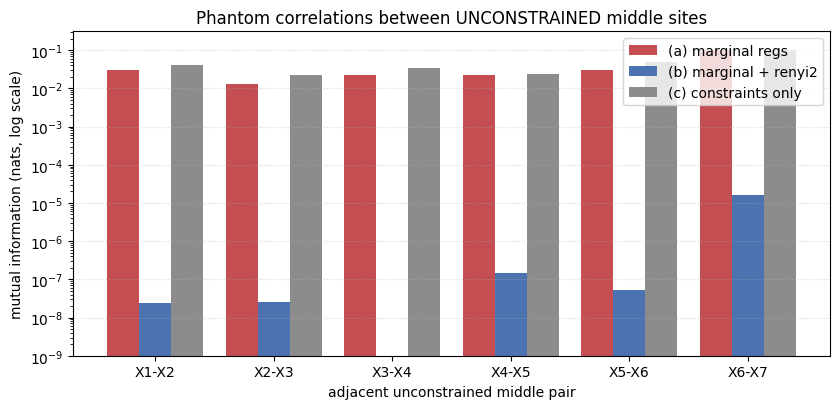

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))
x = np.arange(len(MID_PAIRS))
w = 0.27
ax.bar(x - w, res_a["mi"], w, label="(a) marginal regs", color="#c44e52")
ax.bar(x,     res_b["mi"], w, label="(b) marginal + renyi2", color="#4c72b0")
ax.bar(x + w, res_c["mi"], w, label="(c) constraints only", color="#8c8c8c")
ax.set_yscale("log")
ax.set_ylim(1e-9, max(max(res_c["mi"]), max(res_a["mi"])) * 3)
ax.set_xticks(x)
ax.set_xticklabels([f"X{i}-X{j}" for (i, j) in MID_PAIRS])
ax.set_ylabel("mutual information (nats, log scale)")
ax.set_xlabel("adjacent unconstrained middle pair")
ax.set_title("Phantom correlations between UNCONSTRAINED middle sites")
ax.legend()
ax.grid(axis="y", ls=":", alpha=0.5)
fig.tight_layout()
_FIG = fig

## 3. Weight sweep

How hard should we push? Sweep the `renyi2` weight and watch three things move:

* **constraint SSE** — the endpoints we *asked* for (should stay low, then rise
  once entropy pressure overwhelms the constraints),
* **mean phantom MI** — the correlations we want gone (should fall fast),
* **$H_2 / H_2^{\max}$** — the joint entropy (should climb toward 1).

The marginal regularizers are held fixed; only the `renyi2` weight changes.

In [7]:
WEIGHTS = [0.0, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0]
sweep = []
for w in WEIGHTS:
    regs = MARG_REGS + ([("renyi2", w)] if w > 0 else [])
    r = fit_and_diagnose(regs)
    m, p = r["model"], r["params"]
    cons, _, _ = make_constraints(m)
    sse = float(m.constraint_loss(cons)(p))   # constraint-only SSE (no reg terms)
    sweep.append((w, sse, r["mean_mi"], r["h2"] / r["h2max"], r["resid0"], r["resid7"]))
    print(f"  w={w:5.2f}  SSE={sse:.3e}  meanMI={r['mean_mi']:.3e}  "
          f"H2/max={r['h2']/r['h2max']:.3f}  resid={r['resid0']:.4f},{r['resid7']:.4f}")

ws   = np.array([s[0] for s in sweep])
sses = np.array([s[1] for s in sweep])
mis  = np.array([s[2] for s in sweep])
h2s  = np.array([s[3] for s in sweep])

  w= 0.00  SSE=6.629e-07  meanMI=3.670e-02  H2/max=0.876  resid=0.0006,0.0005


  w= 0.01  SSE=3.729e-07  meanMI=1.960e-03  H2/max=0.927  resid=0.0004,0.0004


  w= 0.03  SSE=4.903e-07  meanMI=4.066e-03  H2/max=0.961  resid=0.0005,0.0005


  w= 0.10  SSE=9.671e-07  meanMI=2.783e-06  H2/max=0.964  resid=0.0006,0.0008


  w= 0.30  SSE=5.656e-06  meanMI=2.559e-06  H2/max=0.965  resid=0.0018,0.0016


  w= 1.00  SSE=3.516e-05  meanMI=1.889e-07  H2/max=0.966  resid=0.0043,0.0040


  w= 3.00  SSE=3.041e-04  meanMI=4.951e-08  H2/max=0.968  resid=0.0122,0.0125


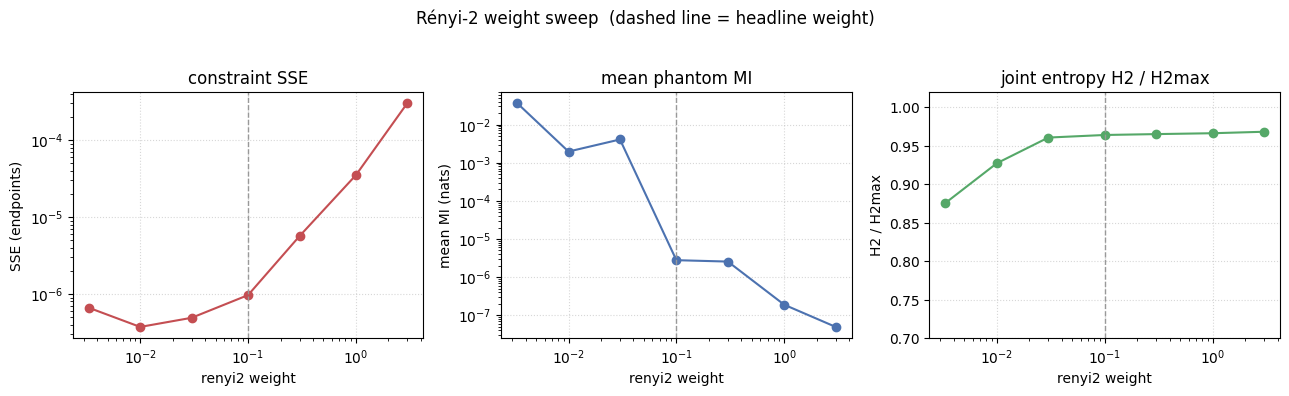

In [8]:
xw = np.where(ws == 0, WEIGHTS[1] / 3.0, ws)   # place w=0 on the log axis
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

axes[0].plot(xw, sses, "o-", color="#c44e52")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_title("constraint SSE"); axes[0].set_xlabel("renyi2 weight")
axes[0].set_ylabel("SSE (endpoints)")

axes[1].plot(xw, np.maximum(mis, 1e-10), "o-", color="#4c72b0")
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_title("mean phantom MI"); axes[1].set_xlabel("renyi2 weight")
axes[1].set_ylabel("mean MI (nats)")

axes[2].plot(xw, h2s, "o-", color="#55a868")
axes[2].set_xscale("log")
axes[2].set_title("joint entropy H2 / H2max"); axes[2].set_xlabel("renyi2 weight")
axes[2].set_ylabel("H2 / H2max"); axes[2].set_ylim(0.7, 1.02)

for ax in axes:
    ax.grid(ls=":", alpha=0.5)
    ax.axvline(RENYI_W, color="0.6", ls="--", lw=1)
fig.suptitle("Rényi-2 weight sweep  (dashed line = headline weight)", y=1.03)
fig.tight_layout()
_FIG = fig

**Reading the sweep.** At small weight the constraint SSE barely moves while
phantom MI already collapses and $H_2$ climbs — the regularizer buys a huge
correlation reduction almost for free. As the weight grows past the point where
entropy pressure starts pulling the constrained endpoint marginals toward
uniform, the constraint SSE turns up: the `renyi2` term is now *fighting* the
`P(X0>60)=0.7` / `E[X0]=70` constraints (a max-entropy chain wants those
marginals flat). The headline weight (dashed line) sits in the sweet spot —
phantom MI already near zero, constraints still tight.

In [9]:
# sanity: entropy climbs monotonically-ish, MI falls, and there IS a tradeoff.
assert h2s[-1] > h2s[0], "joint entropy should rise with renyi2 weight"
assert mis[np.argmax(ws)] < mis[0] / 10.0, "large weight should shrink phantom MI"
assert sses[-1] > sses[0], "SSE should eventually rise as entropy fights constraints"
print("Sweep assertions passed:")
print(f"  H2/max:  {h2s[0]:.3f} (w=0)  ->  {h2s[-1]:.3f} (w={ws[-1]})")
print(f"  meanMI:  {mis[0]:.3e} (w=0)  ->  {mis[-1]:.3e} (w={ws[-1]})")
print(f"  SSE:     {sses[0]:.3e} (w=0)  ->  {sses[-1]:.3e} (w={ws[-1]})  (constraints give under pressure)")

Sweep assertions passed:
  H2/max:  0.876 (w=0)  ->  0.968 (w=3.0)
  meanMI:  3.670e-02 (w=0)  ->  4.951e-08 (w=3.0)
  SSE:     6.629e-07 (w=0)  ->  3.041e-04 (w=3.0)  (constraints give under pressure)


## 4. Cost note: the four-copy transfer scales steeply in $r$

For `kind="born"`, $H_2$ needs the **quadrupled** transfer — a running state of
four bond copies $(r, r, r, r)$ — so its cost grows much faster in the bond
dimension $r$ than the ordinary doubled ($Z$) contraction. A few timings on the
`n=8` chain at `bond_dim` 4 / 8 / 16 (after a JIT warm-up) confirm the steep
$r$-scaling. Keep it quick — this is a spot check, not a benchmark grid.

In [10]:
def time_h2(bond, n_rep=20):
    vs = [ContinuousVar(f"x{i}", 0.0, 100.0, NB) for i in range(N)]
    m = TensorChain(vs, bond_dim=bond, kind="born")
    p = m.init_params(seed=0, init="random")
    f = jax.jit(m.renyi2_entropy)
    f(p).block_until_ready()                      # warm-up (compile)
    t0 = time.perf_counter()
    for _ in range(n_rep):
        f(p).block_until_ready()
    return (time.perf_counter() - t0) / n_rep * 1e3   # ms/call

print(f"{'bond_dim':>8} {'H2 time (ms/call)':>18} {'rel to r=4':>12}")
base = None
timings = []
for bond in (4, 8, 16):
    t = time_h2(bond)
    base = t if base is None else base
    timings.append((bond, t))
    print(f"{bond:8d} {t:18.3f} {t/timings[0][1]:12.1f}x")

print("\nCost rises sharply with r (four-copy state ~ r^4 memory, ~r^5 work) "
      "-- the first thing to feel a large bond dimension for the born kind.")

bond_dim  H2 time (ms/call)   rel to r=4


       4              0.854          1.0x


       8              3.789          4.4x


      16             50.763         59.5x

Cost rises sharply with r (four-copy state ~ r^4 memory, ~r^5 work) -- the first thing to feel a large bond dimension for the born kind.


## Summary

* **Correctness** — `renyi2_entropy` matches brute force to `<1e-3` for both
  kinds; uniform init sits at $\sum_i \log d_i$.
* **Phantom correlations** — constraint fitting with only marginal regularizers
  leaves real mutual information between *unconstrained* middle sites (which no
  marginal regularizer can see or remove). Adding `("renyi2", w)` drives that MI
  down by orders of magnitude while the endpoint constraints stay tight.
* **Tradeoff** — a weight sweep shows phantom MI and joint entropy respond long
  before the constraints do; push too hard and the entropy term starts flattening
  the *constrained* marginals and the constraint SSE rises.
* **Cost** — the born-kind four-copy transfer scales steeply in the bond
  dimension; fine at moderate $r$, the first thing to feel a large one.